# mjo_phase_background

- Plot background for MJO phase-space diagrams
- [NCL: mjo_phase_background](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_phase_background.shtml)

NCL OUTPUT:
<p align="center">
    <img src="https://www.ncl.ucar.edu/Document/Functions/Images/mjo_phase_background_1.png">
</p>

Working Example -- Phase diagram split into 8 equal parts for example:

 <p align="center">
    <img src="https://psl.noaa.gov/mjo/mjoindex/romi_cpcolr_phase_diag.png">
</p>

In [1]:
# Create base of the map for a Phase Diagram
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker # force integar ticks on axis
import matplotlib.lines as lines # add phase division lines
import numpy as np

def mjo_basemap(is_darkmode=False, start_date="Start", end_date="End"):
    if is_darkmode:
        plt.style.use("dark_background") # dark mode for testing
        color_dm = "white"
    else:
        plt.style.use("default")
        color_dm = "black"
    
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111)
    
    # set x and y axis labels
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax2 = ax.twinx() 
    ax3 = ax.twiny()
    ax2.set_xlim(-4, 4)
    ax2.set_ylim(-4, 4)
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-4, 4)
    ax.set_xlabel("Bottom - Phase 2 (Indian Ocean) Phase 3", fontsize=20, labelpad=20)
    ax.set_ylabel("Left - Phase 1 (Western Hemisphere, Africa) Phase 8", fontsize=20, labelpad=20)
    ax2.set_ylabel("Right - Phase 5 (Maritime) Phase 4", fontsize=20, labelpad=40, rotation=270)
    ax3.set_xlabel("Top - Phase 7 (Western Pacific) Phase 6", fontsize=20, labelpad=20)
    
    # add amplitude circle
    amplitude_circle = plt.Circle((0, 0), 1, color=color_dm, fill=False)
    ax.add_patch(amplitude_circle)
    
    # add phase diagram lines
    ## Phase 1-8
    phase_line = lines.Line2D([-4, -1],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 1-2
    phase_line = lines.Line2D([np.cos(3 * np.pi / 4), -4],
                               [np.sin(7 * np.pi / 4), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 2-3
    phase_line = lines.Line2D([0, 0],
                               [-1, -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 3-4
    phase_line = lines.Line2D([np.cos(np.pi / 4), 4],
                               [np.sin(7 * np.pi / 4), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 4-5
    phase_line = lines.Line2D([1, 4],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 5-6
    phase_line = lines.Line2D([np.cos(np.pi / 4), 4],
                               [np.sin(np.pi / 4), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 6-7
    phase_line = lines.Line2D([0, 0],
                               [1, 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 7-8
    phase_line = lines.Line2D([np.cos(3 * np.pi / 4), -4],
                               [np.sin(np.pi / 4), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    
    # add tick marks
    full_tickmarks = np.arange(-4, 4.5, 0.5)
    ax.set_xticks(full_tickmarks)
    ax.set_yticks(full_tickmarks)
    # hide tickmarks for top/right axis)
    ax2.set_yticks(full_tickmarks)
    ax3.set_xticks(full_tickmarks)
    
    # add (optional) phase number text in each segment
    ax.text(-3, -1.5, "1", color=color_dm, fontsize=20)
    ax.text(-1.5, -3, "2", color=color_dm, fontsize=20)
    ax.text(1.5, -3, "3", color=color_dm, fontsize=20)
    ax.text(3, -1.5, "4", color=color_dm, fontsize=20)
    ax.text(3, 1.5, "5", color=color_dm, fontsize=20)
    ax.text(1.5, 3, "6", color=color_dm, fontsize=20)
    ax.text(-1.5, 3, "7", color=color_dm, fontsize=20)
    ax.text(-3, 1.5, "8", color=color_dm, fontsize=20)
    
    # plot whole numbers integar tick marks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    # increase length of major ticks
    ax.tick_params(which="major", length=10)
    ax2.tick_params(which="major", length=10)
    ax3.tick_params(which="major", length=10)

    # plot minor ticks every 0.25
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    # increase length of minor ticks
    ax.tick_params(which="minor", length=5)
    ax2.tick_params(which="minor", length=5)
    ax3.tick_params(which="minor", length=5)

    # plot with title
    plt.title(f"MJO Phase: 15S-15N: {start_date}-{end_date}", fontsize=30, fontweight="bold", pad=20)
    
    plt.show()

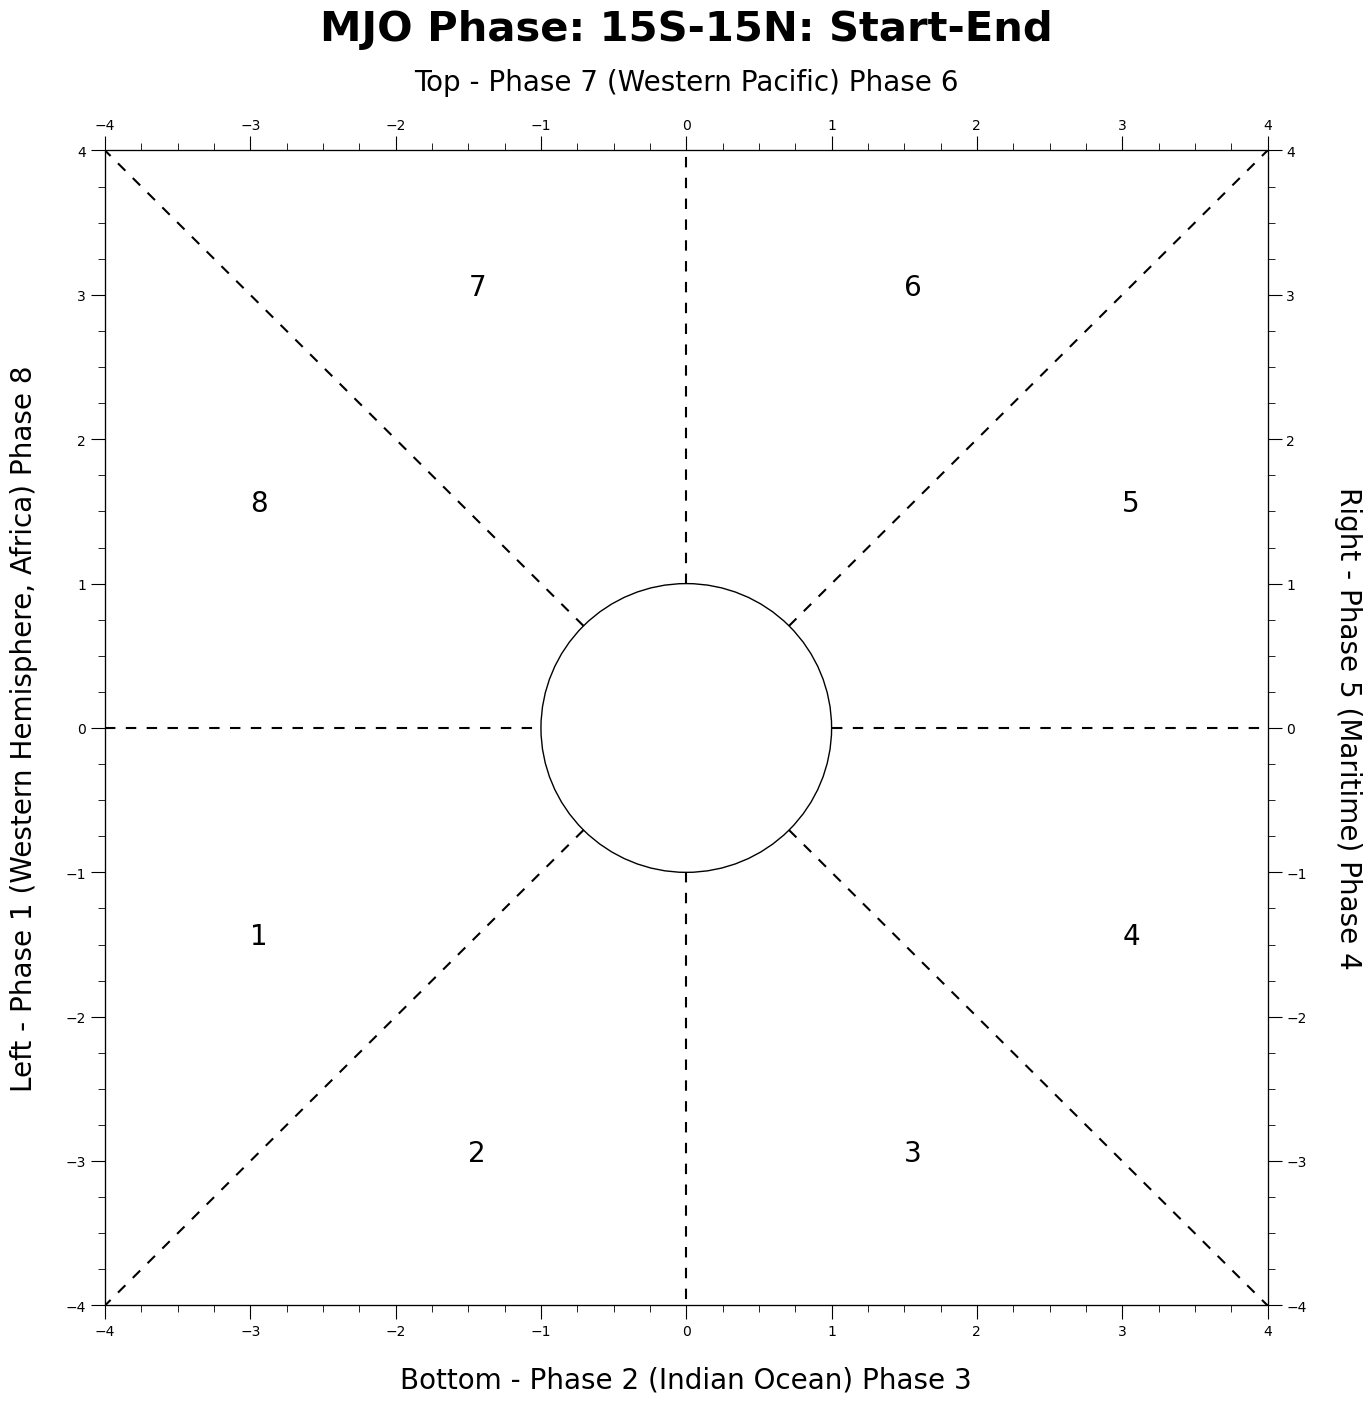

In [2]:
mjo_basemap(is_darkmode=False)